# TEXT EMOTION DETECTION

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import pipeline
from tqdm import tqdm

## Loading the dataset

In [2]:
df = pd.read_csv("dataset.csv")

In [3]:
label_dict = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}


In [4]:
df.head()

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2


In [5]:
conteo = df['label'].value_counts().sort_index()

for label, count in conteo.items():
    print(f"{label} - {label_dict[label]}: {count}")

0 - sadness: 121187
1 - joy: 141067
2 - love: 34554
3 - anger: 57317
4 - fear: 47712
5 - surprise: 14972


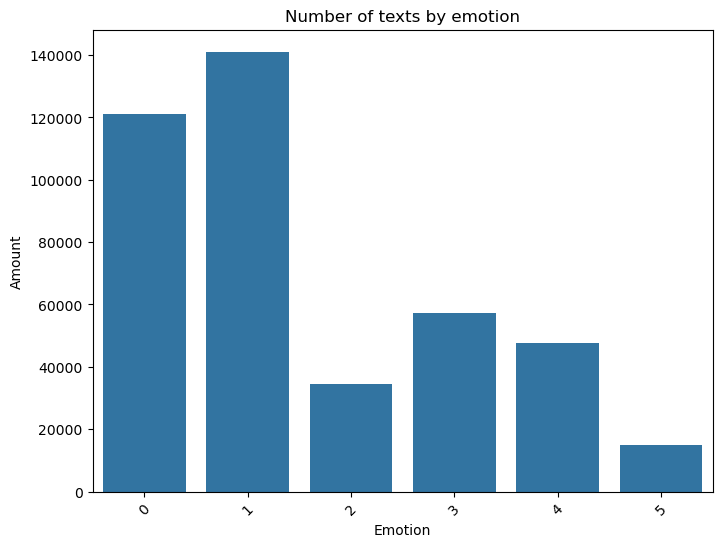

In [6]:
plt.figure(figsize=(8, 6)) 
sns.countplot(x='label', data=df)
plt.title('Number of texts by emotion')
plt.xlabel('Emotion')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.show()

In [12]:
#!pip install transformers

## Create the Emotions Classifier

In [13]:
#!pip install torch

In [14]:
#pip install huggingface_hub[hf_xet]

In [7]:
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"


In [8]:
from transformers import pipeline


## Example of emotion

In [10]:
classifier = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion", return_all_scores=True)

text = "I am very happy with the results"
result = classifier(text)

for emotion in result[0]:
    print(f"{emotion['label']}: {emotion['score']:.4f}")


config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

C:\Users\Diego Maldonado\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Diego Maldonado\.cache\huggingface\hub\models--bhadresh-savani--bert-base-uncased-emotion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


sadness: 0.0007
joy: 0.9979
love: 0.0005
anger: 0.0003
fear: 0.0002
surprise: 0.0002


In [13]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")


CUDA available: True
CUDA device count: 1
CUDA device name: NVIDIA GeForce RTX 3050 Laptop GPU


In [14]:
# Load model (DistilRoBERTa for emotion classification)
classifier = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion", top_k=None, device=0)  # device=0 for GPU, -1 for CPU

# Parameters
batch_size = 64  # try 16, 32, 64 depending on RAM/GPU

# Function to predict in batches
def predict_in_batches(texts, batch_size=32):
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i+batch_size].tolist()
        preds = classifier(batch)
        for item in preds:
            top_emotion = max(item, key=lambda x: x['score'])
            results.append(top_emotion['label'])
    return results

# Run batch predictions
df['predicted_emotion'] = predict_in_batches(df['text'], batch_size=batch_size)

# Save results to CSV
df.to_csv('dataset_with_predictions.csv', index=False)

# Show sample
df[['text', 'predicted_emotion']].head()

Device set to use cuda:0
100%|████████████████████████████████████████████████████████████████████████████| 6513/6513 [1:15:10<00:00,  1.44it/s]


,text,predicted_emotion
0,i feel awful about it too because it s my job ...,sadness
1,im alone i feel awful,sadness
2,ive probably mentioned this before but i reall...,joy
3,i was feeling a little low few days back,sadness
4,i beleive that i am much more sensitive to oth...,love


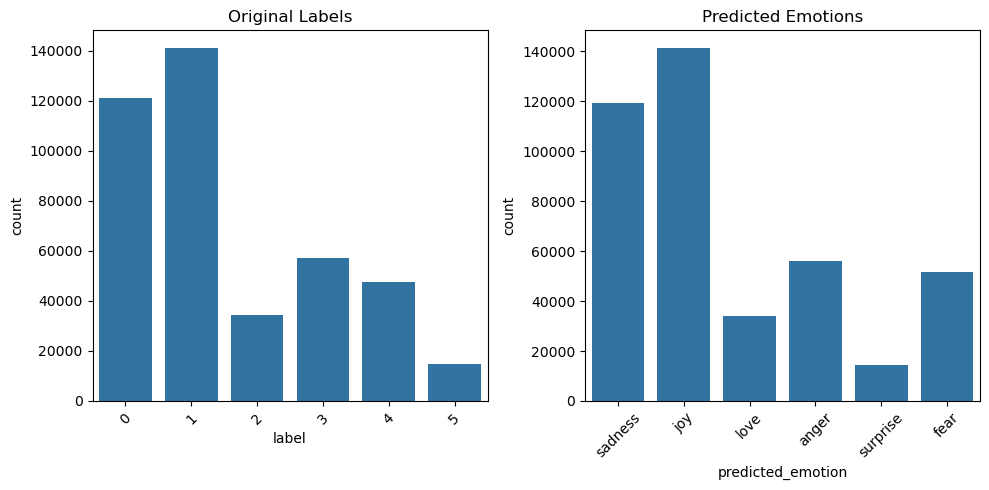

In [15]:
# Compare predicted vs. real label distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='label', data=df)
plt.title('Original Labels')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(x='predicted_emotion', data=df)
plt.title('Predicted Emotions')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
